Originalna dimenzija: (2000, 9479)
Redukovana dimenzija (SVD): (2000, 50)

--- REZULTATI: REDUKOVANI (SVD) ---
       Algoritam     Score
0         KMeans  0.095336
1      MiniBatch  0.074020
2  Agglomerative  0.078420
3       Spectral  0.095870
4         DBSCAN  0.152041


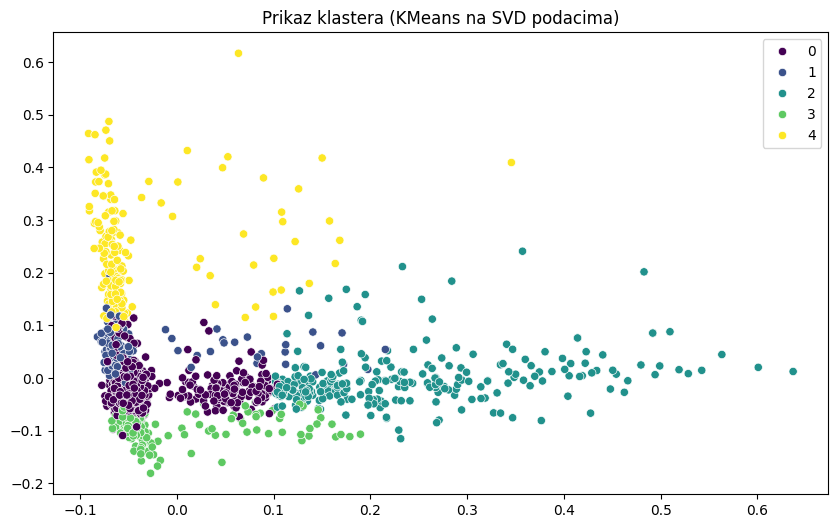

In [7]:
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Ucitavanje i priprema uzorka 
df = pd.read_csv("Reviews_sample_balanced.csv").dropna(subset=['Text']).sample(2000, random_state=42)
df = df.sample(n=2000, random_state=42).reset_index(drop=True)
# Vektorizacija teksta
tfidf = TfidfVectorizer(max_features=15000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['Text']).toarray() 

svd = TruncatedSVD(n_components=50, random_state=42)
X = svd.fit_transform(X_tfidf)

print(f"Originalna dimenzija: {X_tfidf.shape}")
print(f"Redukovana dimenzija (SVD): {X.shape}")

results = {}

# KMeans
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = km.fit_predict(X)
results['KMeans'] = silhouette_score(X, labels_km)

# MiniBatchKMeans
mb = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100)
labels_mb = mb.fit_predict(X)
results['MiniBatch'] = silhouette_score(X, labels_mb)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X)
results['Agglomerative'] = silhouette_score(X, labels_agg)

# Spectral
spec = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
labels_spec = spec.fit_predict(X)
results['Spectral'] = silhouette_score(X, labels_spec)

# DBSCAN (sa proverom)
db = DBSCAN(eps=0.15, min_samples=3).fit(X)
if len(set(db.labels_)) > 1:
    core_mask = db.labels_ != -1
    if len(set(db.labels_[core_mask])) > 1:
        results['DBSCAN'] = float(silhouette_score(X[core_mask], db.labels_[core_mask]))
    else:
        results['DBSCAN'] = 0.0
else:
    results['DBSCAN'] = 0.0

# Tabela
df_res = pd.DataFrame(list(results.items()), columns=['Algoritam', 'Score'])
df_res['Score'] = pd.to_numeric(df_res['Score'], errors='coerce').fillna(0.0)

print("\n--- REZULTATI: REDUKOVANI (SVD) ---")
print(df_res)

# PCA Vizuelizacija
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
plt.figure(figsize=(10,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=km.labels_, palette='viridis', legend='full')
plt.title('Prikaz klastera (KMeans na SVD podacima)')
plt.show()

In [8]:
df_res.to_csv("rezultati_svd.csv", index=False)